In [ ]:
# Importing important libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
base_path = r"C:\Users\USER\OneDrive\Desktop\My_Docs\Google_Data_Analytics (Coursera)\FitBit Data\mturkfitbit_export_3.12.16-4.11.16\Fitabase Data 3.12.16-4.11.16"

In [3]:
# Loading the datasets

daily_activity = pd.read_csv(
    base_path + r"\daily_activity.csv"
)

hourly_steps = pd.read_csv(
    base_path + r"\hourlySteps_merged.csv"
)

hourly_intensity = pd.read_csv(
    base_path + r"\hourlyIntensities_merged.csv"
)

minute_sleep = pd.read_csv(
    base_path + r"\minuteSleep_merged.csv"
)

In [4]:
import os

print(os.listdir(base_path))

['daily_activity.csv', 'heartrate_seconds_merged.csv', 'hourlyCalories_merged.csv', 'hourlyIntensities_merged.csv', 'hourlySteps_merged.csv', 'minuteCaloriesNarrow_merged.csv', 'minuteIntensitiesNarrow_merged.csv', 'minuteMETsNarrow_merged.csv', 'minuteSleep_merged.csv', 'minuteStepsNarrow_merged.csv', 'weightLogInfo_merged.csv']


In [5]:
# Dataset overview

datasets = {
    "Daily Activity": daily_activity,
    "Hourly Steps": hourly_steps,
    "Hourly Intensity": hourly_intensity,
    "Minute Sleep": minute_sleep
}

for name, df in datasets.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nUnique Users:")
    print(df["Id"].nunique())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())


Daily Activity
Shape: (457, 16)

Columns:
['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'Day']

Unique Users:
35

Missing Values:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
Day                         0
dtype: int64

Duplicate Rows:
0

Hourly Steps
Shape: (24084, 3)

Columns:
['Id', 'ActivityHour', 'StepTotal']

Unique Users:
34

Missi

In [8]:
# Cleaning date columns

# Daily Activity

daily_activity["ActivityDate"] = pd.to_datetime(
    daily_activity["ActivityDate"],
    errors="coerce"
)


# Hourly Steps

hourly_steps["ActivityHour"] = pd.to_datetime(
    hourly_steps["ActivityHour"],
    errors="coerce"
)


# Hourly Intensity

hourly_intensity["ActivityHour"] = pd.to_datetime(
    hourly_intensity["ActivityHour"],
    errors="coerce"
)


# Minute Sleep

minute_sleep["date"] = pd.to_datetime(
    minute_sleep["date"],
    errors="coerce"
)

In [9]:
# Analyzing daily activity

daily_activity.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,4.570000e+02,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,4.628595e+09,6546.562363,4.663523,4.609847,0.179427,1.180897,0.478643,2.890197,0.001904,16.623632,13.070022,170.070022,995.282276,2189.452954
std,2.293781e+09,5398.493064,4.082072,4.068540,0.849232,2.487159,0.830995,2.237523,0.008487,28.919704,36.208635,122.205372,337.021404,815.484523
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,0.000000
25%,2.347168e+09,1988.000000,1.410000,1.280000,0.000000,0.000000,0.000000,0.870000,0.000000,0.000000,0.000000,64.000000,728.000000,1776.000000
50%,4.057193e+09,5986.000000,4.090000,4.090000,0.000000,0.000000,0.020000,2.930000,0.000000,0.000000,1.000000,181.000000,1057.000000,2062.000000
75%,6.391747e+09,10198.000000,7.160000,7.110000,0.000000,1.310000,0.670000,4.460000,0.000000,25.000000,16.000000,257.000000,1285.000000,2667.000000
max,8.877689e+09,28497.000000,27.530000,27.530000,6.727057,21.920000,6.400000,12.510000,0.100000,202.000000,660.000000,720.000000,1440.000000,4562.000000


In [10]:
# Key metrics

print("Average Steps:",
      round(daily_activity["TotalSteps"].mean(), 0))

print("Average Calories:",
      round(daily_activity["Calories"].mean(), 0))

print("Average Sedentary Minutes:",
      round(daily_activity["SedentaryMinutes"].mean(), 0))

print("Average Very Active Minutes:",
      round(daily_activity["VeryActiveMinutes"].mean(), 0))

Average Steps: 6547.0
Average Calories: 2189.0
Average Sedentary Minutes: 995.0
Average Very Active Minutes: 17.0


In [11]:
# Activity by day of week

daily_activity["DayOfWeek"] = (
    daily_activity["ActivityDate"].dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

activity_by_day = (
    daily_activity
    .groupby("DayOfWeek")
    [["TotalSteps", "Calories",
      "VeryActiveMinutes",
      "SedentaryMinutes"]]
    .mean()
    .reindex(day_order)
)

print(activity_by_day.round(2))

           TotalSteps  Calories  VeryActiveMinutes  SedentaryMinutes
DayOfWeek                                                           
Monday        7118.59   2252.87              18.96           1032.85
Tuesday       4914.92   1742.42              13.15            850.25
Wednesday     7510.71   2377.46              16.98           1011.06
Thursday      6847.08   2297.81              17.44           1055.06
Friday        6737.56   2313.55              16.00           1054.71
Saturday      7089.77   2277.59              18.97            976.63
Sunday        6058.01   2167.60              15.35           1015.65


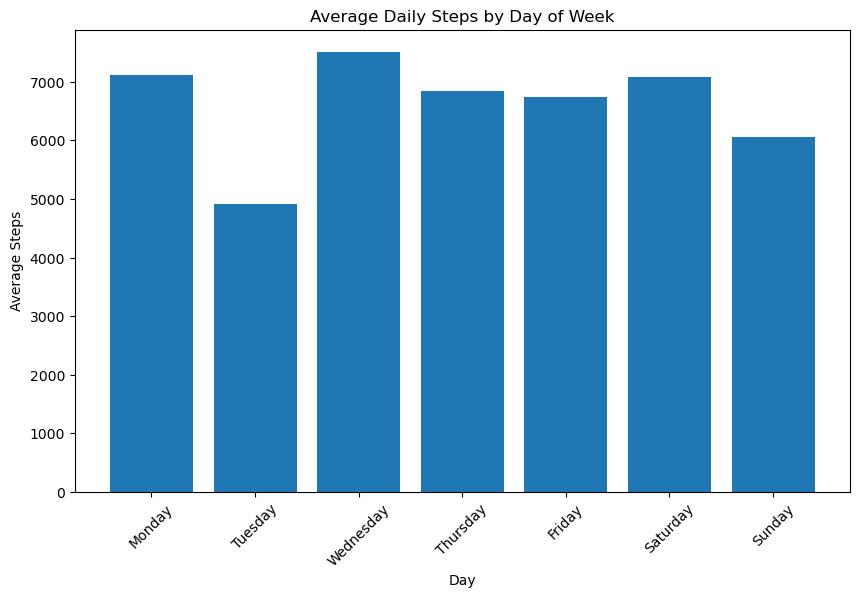

In [15]:
# Visualization

plt.figure(figsize=(10, 6))

plt.bar(
    activity_by_day.index,
    activity_by_day["TotalSteps"]
)

plt.title("Average Daily Steps by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Steps")

plt.xticks(rotation=45)

plt.show()

In [17]:
# Analyzing hourly steps

hourly_steps["Hour"] = (
    hourly_steps["ActivityHour"].dt.hour
)

# Calculating activity by hour
steps_by_hour = (
    hourly_steps
    .groupby("Hour")["StepTotal"]
    .mean()
)

print(steps_by_hour.round(2))

Hour
0      44.42
1      20.48
2      10.59
3       7.31
4       9.76
5      26.11
6     120.16
7     267.12
8     365.60
9     430.26
10    437.00
11    452.75
12    520.94
13    457.88
14    474.12
15    390.47
16    447.37
17    453.66
18    505.65
19    528.88
20    399.32
21    261.01
22    172.98
23    102.90
Name: StepTotal, dtype: float64


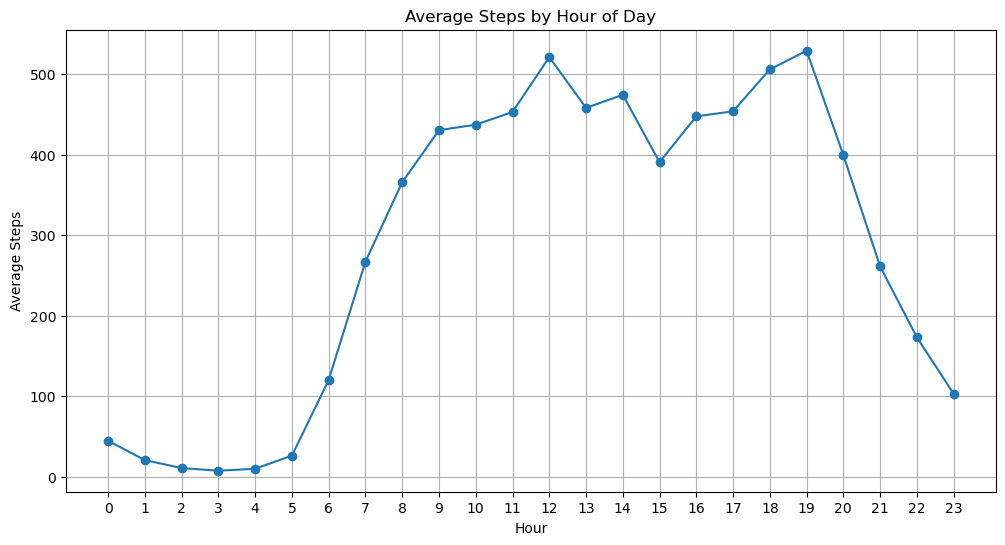

In [18]:
# Visualization

plt.figure(figsize=(12, 6))

plt.plot(
    steps_by_hour.index,
    steps_by_hour.values,
    marker="o"
)

plt.title("Average Steps by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Steps")

plt.xticks(range(24))

plt.grid()

plt.show()

In [19]:
# Activity intensity by hour
hourly_intensity["Hour"] = (
    hourly_intensity["ActivityHour"].dt.hour
)

intensity_by_hour = (
    hourly_intensity
    .groupby("Hour")
    [["TotalIntensity", "AverageIntensity"]]
    .mean()
)

print(intensity_by_hour.round(2))

      TotalIntensity  AverageIntensity
Hour                                  
0               2.41              0.04
1               1.32              0.02
2               0.76              0.01
3               0.55              0.01
4               0.58              0.01
5               3.84              0.06
6               5.54              0.09
7               9.61              0.16
8              12.71              0.21
9              15.25              0.25
10             15.89              0.26
11             16.63              0.28
12             18.54              0.31
13             16.29              0.27
14             17.02              0.28
15             14.99              0.25
16             16.44              0.27
17             17.81              0.30
18             18.52              0.31
19             19.25              0.32
20             14.92              0.25
21             10.34              0.17
22              7.41              0.12
23              4.57     

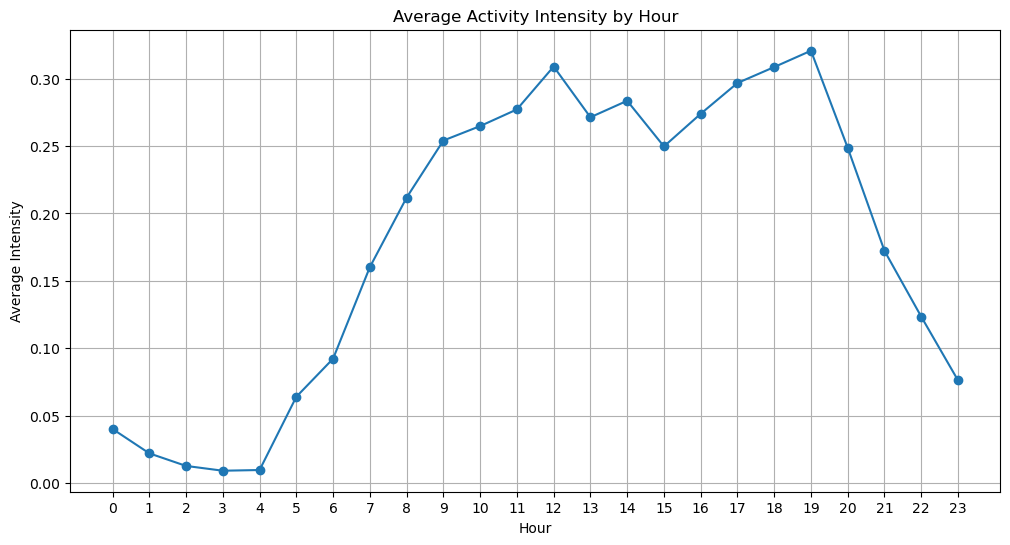

In [21]:
# Visualization

plt.figure(figsize=(12, 6))

plt.plot(
    intensity_by_hour.index,
    intensity_by_hour["AverageIntensity"],
    marker="o"
)

plt.title("Average Activity Intensity by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Intensity")

plt.xticks(range(24))

plt.grid()

plt.show()

In [23]:
# Analyze minute sleep data

print(minute_sleep.head())

print(minute_sleep.columns)

print(minute_sleep["value"].value_counts())

           Id                date  value        logId
0  1503960366 2016-03-13 02:39:30      1  11114919637
1  1503960366 2016-03-13 02:40:30      1  11114919637
2  1503960366 2016-03-13 02:41:30      1  11114919637
3  1503960366 2016-03-13 02:42:30      1  11114919637
4  1503960366 2016-03-13 02:43:30      1  11114919637
Index(['Id', 'date', 'value', 'logId'], dtype='object')
1    183526
2     13010
3      2023
Name: value, dtype: int64


In [26]:
# Creating a date-only column

minute_sleep["Date"] = (
    minute_sleep["date"].dt.date
)

# Calculating daily sleep metrics

daily_sleep = (
    minute_sleep
    .groupby(["Id", "Date"])
    .agg(
        SleepMinutes=("value", "count"),
        AverageSleepValue=("value", "mean")
    )
    .reset_index()
)

# Converting to hours

daily_sleep["SleepHours"] = (
    daily_sleep["SleepMinutes"] / 60
)

print(daily_sleep.head())

           Id        Date  SleepMinutes  AverageSleepValue  SleepHours
0  1503960366  2016-03-13           426           1.035211    7.100000
1  1503960366  2016-03-14           386           1.095855    6.433333
2  1503960366  2016-03-15           335           1.089552    5.583333
3  1503960366  2016-03-16           366           1.103825    6.100000
4  1503960366  2016-03-17           437           1.082380    7.283333


In [27]:
minute_sleep["value"].value_counts()

1    183526
2     13010
3      2023
Name: value, dtype: int64

In [30]:
# Merging daily activity with sleep

daily_activity["Date"] = (
    daily_activity["ActivityDate"].dt.date
)

# Merge

activity_sleep = pd.merge(
    daily_activity,
    daily_sleep,
    on=["Id", "Date"],
    how="inner"
)

print("Merged Dataset Shape:")
print(activity_sleep.shape)

print("Unique Users:")
print(activity_sleep["Id"].nunique())

Merged Dataset Shape:
(199, 21)
Unique Users:
20


In [31]:
# Activity VS Sleep analysis

correlation_columns = [
    "TotalSteps",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes",
    "Calories",
    "SleepHours"
]

correlation = (
    activity_sleep[correlation_columns]
    .corr()
)

print(correlation.round(2))

                      TotalSteps  VeryActiveMinutes  FairlyActiveMinutes  \
TotalSteps                  1.00               0.56                 0.57   
VeryActiveMinutes           0.56               1.00                 0.31   
FairlyActiveMinutes         0.57               0.31                 1.00   
LightlyActiveMinutes        0.68               0.01                 0.22   
SedentaryMinutes           -0.09              -0.07                -0.09   
Calories                    0.35               0.46                 0.26   
SleepHours                 -0.16              -0.15                -0.06   

                      LightlyActiveMinutes  SedentaryMinutes  Calories  \
TotalSteps                            0.68             -0.09      0.35   
VeryActiveMinutes                     0.01             -0.07      0.46   
FairlyActiveMinutes                   0.22             -0.09      0.26   
LightlyActiveMinutes                  1.00             -0.08      0.27   
SedentaryMinutes     

In [32]:
print(
    "Steps vs Sleep Hours:",
    activity_sleep["TotalSteps"].corr(
        activity_sleep["SleepHours"]
    )
)

Steps vs Sleep Hours: -0.15576098659328463


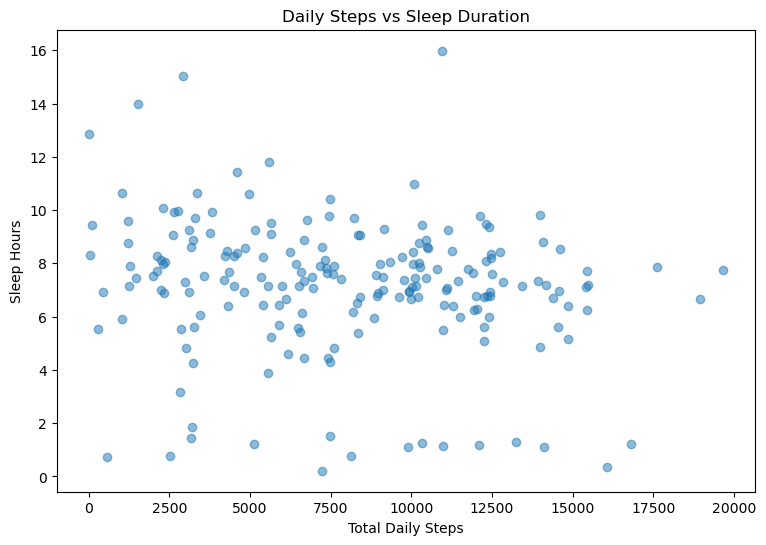

In [34]:
# Steps VS Sleep visualization

plt.figure(figsize=(9, 6))

plt.scatter(
    activity_sleep["TotalSteps"],
    activity_sleep["SleepHours"],
    alpha=0.5
)

plt.title("Daily Steps vs Sleep Duration")
plt.xlabel("Total Daily Steps")
plt.ylabel("Sleep Hours")

plt.show()

In [36]:
# User segmentation

def activity_level(steps):

    if steps < 5000:
        return "Low Activity"

    elif steps < 10000:
        return "Moderate Activity"

    else:
        return "High Activity"


daily_activity["ActivityLevel"] = (
    daily_activity["TotalSteps"]
    .apply(activity_level)
)

# Checking segments

print(
    daily_activity["ActivityLevel"]
    .value_counts()
)

Low Activity         197
Moderate Activity    133
High Activity        127
Name: ActivityLevel, dtype: int64


In [37]:
# Creating final user summary

user_summary = (
    daily_activity
    .groupby("Id")
    .agg(
        AvgDailySteps=("TotalSteps", "mean"),
        AvgCalories=("Calories", "mean"),
        AvgVeryActiveMinutes=("VeryActiveMinutes", "mean"),
        AvgSedentaryMinutes=("SedentaryMinutes", "mean"),
        RecordedDays=("ActivityDate", "count")
    )
    .reset_index()
)

print(user_summary.round(2))

            Id  AvgDailySteps  AvgCalories  AvgVeryActiveMinutes  \
0   1503960366       11640.53      1796.21                 35.84   
1   1624580081        4226.26      1352.89                  0.74   
2   1644430081        9274.80      2916.40                 14.80   
3   1844505072        3640.58      1615.92                  0.75   
4   1927972279        2180.83      2254.00                  0.00   
5   2022484408       12174.92      2475.33                 40.08   
6   2026352035        3392.75      1355.50                  0.00   
7   2320127002        3138.42      1532.08                  0.92   
8   2347167796        9800.07      2021.33                 11.80   
9   2873212765        6636.58      1695.75                  5.08   
10  2891001357         773.62      2273.38                  0.00   
11  3372868164        6127.50      1860.30                 11.80   
12  3977333714        8663.92      1398.08                 12.17   
13  4020332650        5776.59      3075.38      

In [38]:
# Exporting dataset for dashboard

daily_activity.to_csv(
    "cleaned_daily_activity.csv",
    index=False
)

daily_sleep.to_csv(
    "daily_sleep_summary.csv",
    index=False
)

activity_sleep.to_csv(
    "activity_sleep_analysis.csv",
    index=False
)

user_summary.to_csv(
    "user_summary.csv",
    index=False
)

In [40]:
import os

for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

activity_sleep_analysis.csv
cleaned_daily_activity.csv
daily_sleep_summary.csv
user_summary.csv
